# 06 · experiment/image — federated melanoma triage on DermaMNIST

Track notebook for the `experiment/image` branch. Dataset: **MedMNIST DermaMNIST**
(28×28 dermoscopy, HAM10000-derived; payload, checksums and the CC BY-NC 4.0 research-only
terms in `data/external/SOURCES.md`). Target: **melanoma vs the six other lesion classes** —
the GP skin-cancer triage question, kept binary so the repo's single model class (logistic
regression, CLAUDE.md rule 2) and the dual-level imbalanced-data metrics (rule 5) apply
unchanged.

The federation is *simulated*: `data/external/dermamnist_to_clinics.py` pools the official
splits and re-partitions into 10 Dirichlet label-skewed pseudo-practices (α = 0.5, accepted
draw seed 45 under the ≥5-positives-per-clinic guard — see
`data/clinics_dermamnist/suite_meta.json`). Clients see flattened pixels (`f0000`–`f2351`);
updates are averaged by Flower's real FedAvg (`simulate.run_simulation`), exactly as in the
CKD tracks.

Prerequisites (once per clone; both payloads are gitignored): `uv run python -m
data.external.dermamnist_to_clinics` after re-downloading the npz per SOURCES.md.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent  # nbconvert executes with cwd=notebooks/
CLINICS = ROOT / 'data/clinics_dermamnist'
NPZ = ROOT / 'data/external/dermamnist/dermamnist.npz'
assert CLINICS.exists(), 'run: uv run python -m data.external.dermamnist_to_clinics'

meta = json.loads((CLINICS / 'suite_meta.json').read_text())
roster = pd.DataFrame(meta['clinics']).set_index('name')[['n', 'mel_rate']]
print(meta['source'])
print('target:', meta['label'])
print('pooled prevalence:', meta['prevalence'], ' over', meta['n_images'], 'images\n')
print(roster.to_string())

MedMNIST DermaMNIST 28x28 (Zenodo 10519652; HAM10000-derived)
target: melanoma = dx class 'mel' (binary; other six lesion classes pooled)
pooled prevalence: 0.1111  over 10015 images

             n  mel_rate
name                    
shard-00  1707    0.0662
shard-01   428    0.3178
shard-02   361    0.1219
shard-03   968    0.3202
shard-04   506    0.0968
shard-05    40    0.1250
shard-06   875    0.2023
shard-07   245    0.1878
shard-08  2309    0.0243
shard-09  2576    0.0687


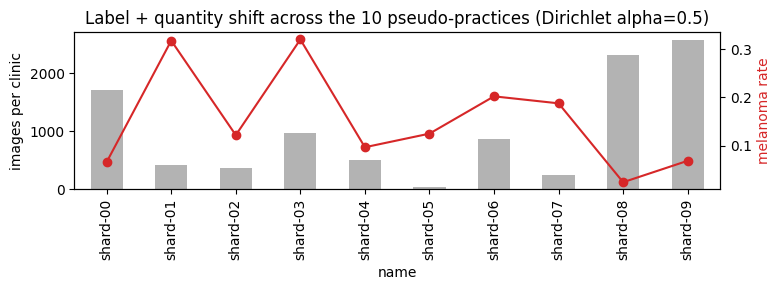

In [2]:
fig, ax1 = plt.subplots(figsize=(8, 3))
roster['n'].plot.bar(ax=ax1, color='0.7')
ax2 = ax1.twinx()
ax2.plot(roster.index, roster['mel_rate'], 'o-', color='tab:red')
ax1.set_ylabel('images per clinic')
ax2.set_ylabel('melanoma rate', color='tab:red')
ax1.set_title('Label + quantity shift across the 10 pseudo-practices (Dirichlet alpha=0.5)')
plt.tight_layout()
plt.show()

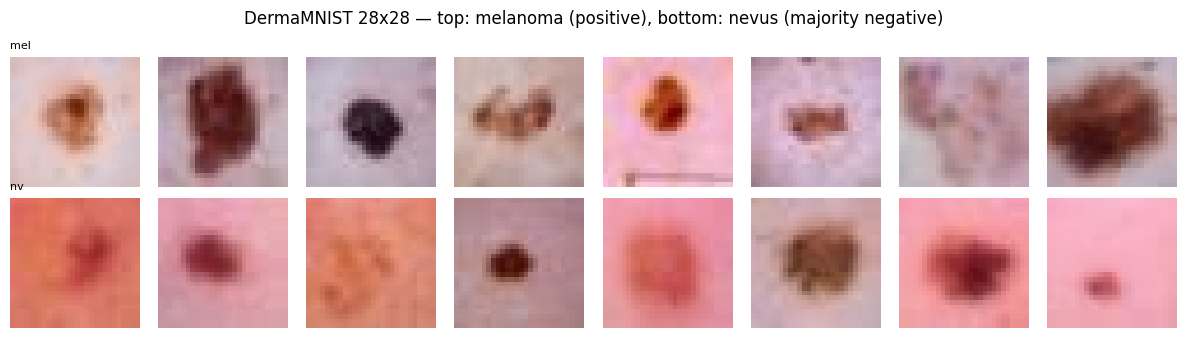

In [3]:
z = np.load(NPZ)
imgs, labels = z['train_images'], z['train_labels'].ravel()
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for row, cls in enumerate([4, 5]):  # melanoma vs the majority nevus class
    picks = np.where(labels == cls)[0][:8]
    for ax, p in zip(axes[row], picks):
        ax.imshow(imgs[p]); ax.axis('off')
    axes[row][0].set_title({4: 'mel', 5: 'nv'}[cls], loc='left', fontsize=8)
plt.suptitle('DermaMNIST 28x28 — top: melanoma (positive), bottom: nevus (majority negative)')
plt.tight_layout()
plt.show()

In [4]:
from simulate import run_simulation

history = run_simulation(num_practices=10, num_rounds=15, quiet=True,
                         clinics_dir=str(CLINICS))
curve = pd.DataFrame(history)[['auc', 'auc_worst', 'sensitivity', 'sensitivity_worst']]
curve.index.name = 'round'
curve.index = curve.index + 1
curve.round(3)

Flower FedAvg (in-process) | model=logreg source=on-disk clinics (10 practices) rounds=15
----------------------------------------------------------------


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


  round  1: AUROC=0.652 (worst practice 0.595)  sensitivity=0.668


INFO :      aggregate_train: Received 10 results and 0 failures


...

  round 14: AUROC=0.693 (worst practice 0.640)  sensitivity=0.467


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


  round 15: AUROC=0.619 (worst practice 0.535)  sensitivity=0.493


,auc,auc_worst,sensitivity,sensitivity_worst
round,,,,
1,0.652,0.595,0.668,0.609
2,0.545,0.436,0.532,0.385
3,0.686,0.614,0.586,0.424
4,0.590,0.501,0.528,0.385
5,0.598,0.506,0.521,0.385
6,0.697,0.637,0.535,0.424
7,0.698,0.635,0.559,0.455
8,0.610,0.544,0.541,0.435
9,0.615,0.538,0.544,0.364


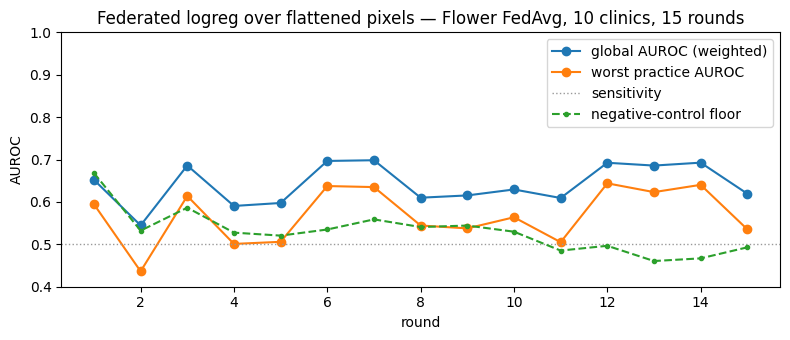

round 15: AUROC 0.619 | worst practice 0.535 | sensitivity 0.493


In [5]:
ax = curve[['auc', 'auc_worst']].plot(figsize=(8, 3.5), marker='o', ylim=(0.4, 1.0),
    title='Federated logreg over flattened pixels — Flower FedAvg, 10 clinics, 15 rounds',
    ylabel='AUROC')
ax.axhline(0.5, color='0.6', ls=':', lw=1)
curve['sensitivity'].plot(ax=ax, ls='--', color='tab:green', marker='.')
ax.legend(['global AUROC (weighted)', 'worst practice AUROC', 'sensitivity',
           'negative-control floor'])
plt.tight_layout()
plt.show()
final = curve.iloc[-1]
print('round 15: AUROC %.3f | worst practice %.3f | sensitivity %.3f'
      % (final['auc'], final['auc_worst'], final['sensitivity']))

## State of the track (measured in this notebook, seed 42, 15 rounds)

- **Signal is real**: global AUROC lives in the 0.61–0.70 band against the 0.5 floor — a
  linear model over 2,352 raw pixels does learn lesion signal federated, with the worst
  practice close behind the weighted mean (the label-skewed shards are a hard non-IID test).
- **But it oscillates round to round**, unlike the CKD tracks that settle by round 10:
  `SGDClassifier`'s adaptive step size on 2,352 features × 2 local epochs per round lets each
  client overshoot on its skewed shard before averaging re-centres it. That is the first
  *protocol* work this branch exists for: local-epoch / learning-rate scheduling, then FedProx
  μ. `/255` pixel normalisation would change nothing — per-client StandardScaler already
  absorbs affine input transforms; the oscillation is optimizer dynamics, not scaling.
- **Deliberately out of scope here** (consortium decisions, not branch work): the 64×64
  payload, the 7-class label, and any non-linear image model (CLAUDE.md rule 2).
- No protected attributes exist at this payload level, so the T2.5 fairness audit does not
  apply. The privacy machinery (patient-level DP-SGD inside the client, SecAgg+ on the wire)
  is dimension-agnostic as a *mechanism* and applies to the 2,353-parameter weight vector —
  but the *cost* already shifts with width: at fixed clipping norm C and noise multiplier σ
  the Gaussian fills all p coordinates, so noise-to-signal grows roughly like sqrt(p). On ten
  features this was background; on 2,353 it is a budget line; on a deep net it dominates.